In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qubic

from FastNoiseSimulator import *

%matplotlib inline

In [2]:
# QUBIC frequency bands in GHz
nus = np.array([150, 220])

nside = 256

# NEP for detectors and photon noises for QUBIC
NEP_det = [4.7e-17, 4.7e-17]
NEP_pho = [3.1e-17, 1.17e-16]

In [3]:
# From NEPs, we compute NETs and from NETs, we compute depths using analytical_forecast_lib.py
NEPs = np.zeros((len(nus), 2))
for i in range(len(nus)):
    NEPs[i, 0] = NEP_det[i] * 2     
    NEPs[i, 1] = NEP_pho[i]
NETs = np.zeros(len(nus))
for i in range(len(nus)):
    NETs[i] = NoiseEquivalentTemperature(NEPs[i], nus[i]).NETs

depths_FMM = AnalyticalForecast(nus, NEP_det, NEP_pho)._get_effective_depths(NETs)

In [4]:
# We compute noise frequency maps
FMM_noise = FastNoise(nus, nside, NEP_det, NEP_pho).get_noise_realisation_FMM()

/pbs/throng/qubic/Anaconda3/envs/qubic_python38/lib/python3.8/site-packages/healpy/projaxes.py:202: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.
  aximg = self.imshow(


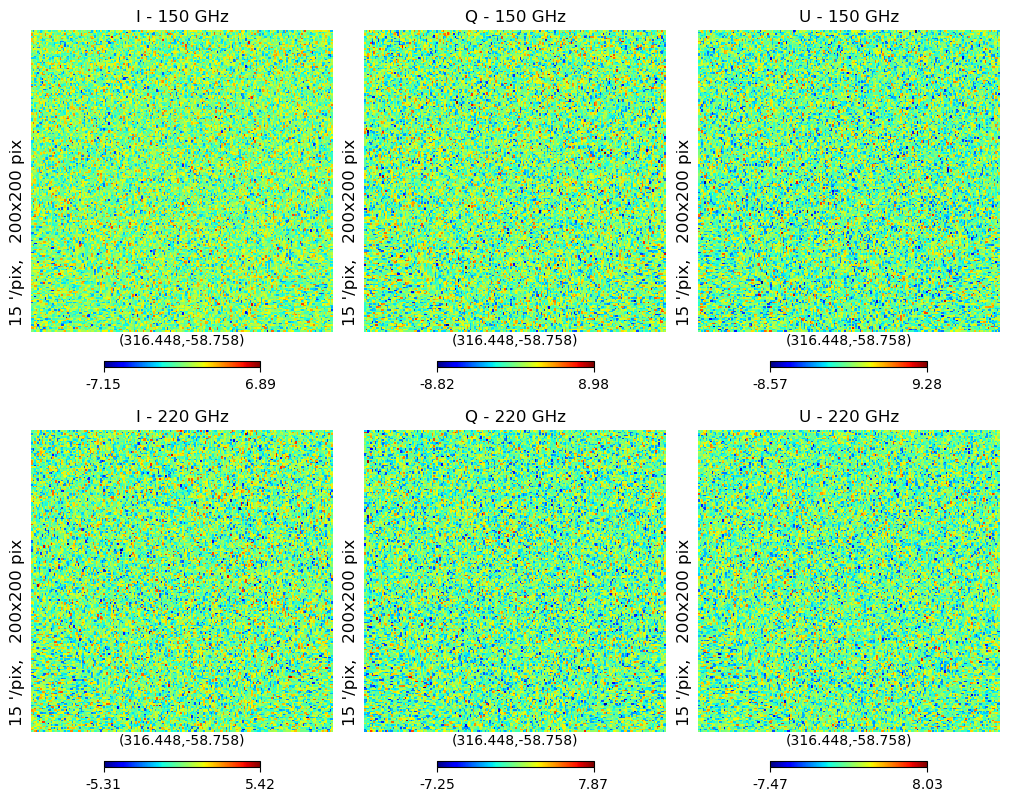

In [5]:
center = qubic.equ2gal(0, -57)
nrec = 2

plt.figure(figsize=(10,8))
k=0
for irec in range(nrec):
    k+=1
    hp.gnomview(FMM_noise[irec, 0, :], cmap='jet', sub=(nrec, 3, k), rot=center, reso=15, title=f'I - {nus[irec]} GHz')
    k+=1
    hp.gnomview(FMM_noise[irec, 1, :], cmap='jet', sub=(nrec, 3, k), rot=center, reso=15, title=f'Q - {nus[irec]} GHz')
    k+=1
    hp.gnomview(FMM_noise[irec, 2, :], rot=center, sub=(nrec, 3, k), reso=15, cmap='jet', title=f'U - {nus[irec]} GHz')

In [6]:
# We compute noise components (CMB + Dust) maps
CMM_noise = FastNoise(nus, nside, NEP_det, NEP_pho, sky = 'CMB + Dust').get_noise_realisation_CMM()

/sps/qubic/Users/TomLaclavere/FastNoise/FastNoiseSimulator.py:83: RuntimeWarning: invalid value encountered in sqrt
  depths_CMM[i] = np.sqrt(np.linalg.pinv(AtNA))[0][i, i] * hp.nside2resol(self.nside, True)


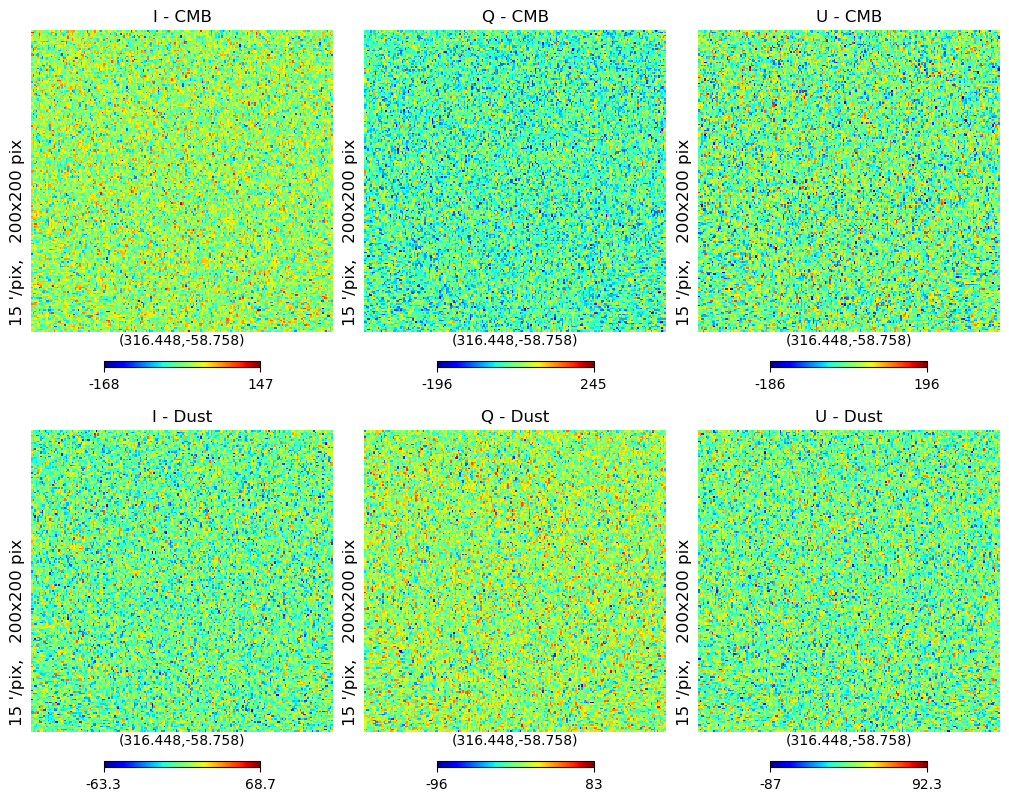

In [7]:
comp = np.array(['CMB', 'Dust'])
ncomp = comp.shape[0]

plt.figure(figsize=(10,8))
k=0
for icomp in range(ncomp):
    k+=1
    hp.gnomview(CMM_noise[icomp, 0, :], cmap='jet', sub=(nrec, 3, k), rot=center, reso=15, title=f'I - {comp[icomp]}')
    k+=1
    hp.gnomview(CMM_noise[icomp, 1, :], cmap='jet', sub=(nrec, 3, k), rot=center, reso=15, title=f'Q - {comp[icomp]}')
    k+=1
    hp.gnomview(CMM_noise[icomp, 2, :], rot=center, sub=(nrec, 3, k), reso=15, cmap='jet', title=f'U - {comp[icomp]}')